In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings 
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('cleaned_data.csv')

In [3]:
df.info()
df['Age'].unique()
df

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,32.3,33.6,0.627,50,1
1,1,85.0,66.0,29.0,32.3,26.6,0.351,31,0
2,8,183.0,64.0,29.0,32.3,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,32.3,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,32.3,30.1,0.349,47,1


In [4]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df[['Outcome']]

In [5]:
sc = StandardScaler()
table = pd.DataFrame(data = sc.fit_transform(X), columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])

In [6]:
x_train, x_test, y_train, y_test = train_test_split(table, y, test_size = 0.1, random_state = 32, stratify = y)

In [7]:
smote = SMOTE(random_state = 42)
x_sampled, y_sampled = smote.fit_resample(x_train, y_train)

In [8]:
model = SVC(kernel = 'rbf')
model.fit(x_sampled, y_sampled)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [9]:
y_pred = model.predict(x_test)
y_pred = pd.DataFrame(data = y_pred, columns = ['Prediction'])
connect = pd.concat([y_test.reset_index(drop = True), y_pred], axis = 1)
result = confusion_matrix(connect['Outcome'], connect['Prediction'])
score = accuracy_score(connect['Outcome'], connect['Prediction'])

In [10]:
print(result)
print(score)

[[42  8]
 [ 7 20]]
0.8051948051948052


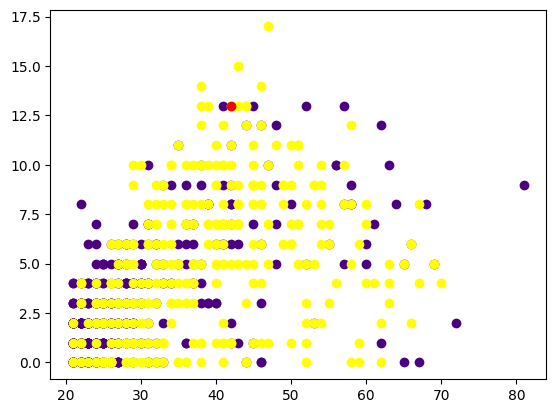

In [11]:
y_pred = model.predict(table)
x0 = X[y_pred == 0]
x1 = X[y_pred == 1]
plt.scatter(x0['Age'], x0['Pregnancies'], color = 'indigo')
plt.scatter(x1['Age'], x1['Pregnancies'], color = 'yellow')
plt.scatter(42, 13, color = 'red')
plt.show()

In [12]:
'''myip = [[13, 52.0, 47.0, 40.0, 50.9, 45.0, 0.627, 42 ]]
scaled = sc.transform(myip)
frame = pd.DataFrame(data = scaled, columns =  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])
result = model.predict(frame)
if result[0] == 1:
    print('Diabetic')
else:
    print('Not diabetic')'''

"myip = [[13, 52.0, 47.0, 40.0, 50.9, 45.0, 0.627, 42 ]]\nscaled = sc.transform(myip)\nframe = pd.DataFrame(data = scaled, columns =  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',\n       'BMI', 'DiabetesPedigreeFunction', 'Age'])\nresult = model.predict(frame)\nif result[0] == 1:\n    print('Diabetic')\nelse:\n    print('Not diabetic')"

In [13]:
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(sc, open('sc.pkl', 'wb'))

In [16]:
print(model.predict(x_test[:10]))
print(y_test[:10].values)

[1 0 1 1 1 1 0 0 1 0]
[[1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]]
